In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look clean
sns.set_theme(style="darkgrid")

In [5]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")

df.head()           # first 5 rows
df.shape            # rows and columns
df.info()           # column types
df.isnull().sum()   # missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null    

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
Unnamed: 12     8809
Unnamed: 13     8809
Unnamed: 14     8809
Unnamed: 15     8809
Unnamed: 16     8809
Unnamed: 17     8809
Unnamed: 18     8809
Unnamed: 19     8809
Unnamed: 20     8809
Unnamed: 21     8809
Unnamed: 22     8809
Unnamed: 23     8809
Unnamed: 24     8809
Unnamed: 25     8809
dtype: int64

In [19]:
df['director'].fillna("Unknown",inplace = True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)


# Convert to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Remove rows with missing dates (optional)
df = df.dropna(subset=["date_added"])

# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Create new columns
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3
8807,s8808,TV Show,Parasyte: The Grey,Yeon Sang-ho,"Shin Hyun-been, Jeon Yeo-bin, Goo Kyo-hwan",South Korea,2024-04-05,2024,TV-MA,1 Season,"Sci-fi, Horror, Action",A new breed of parasitic aliens arrive on Eart...,2024,4


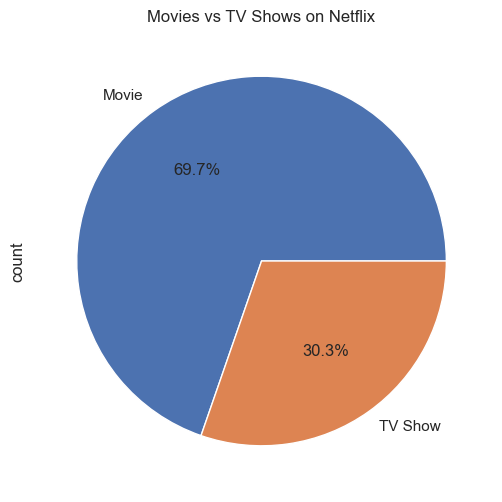

In [20]:
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("charts/movies_vs_tvshows.png")
plt.show()

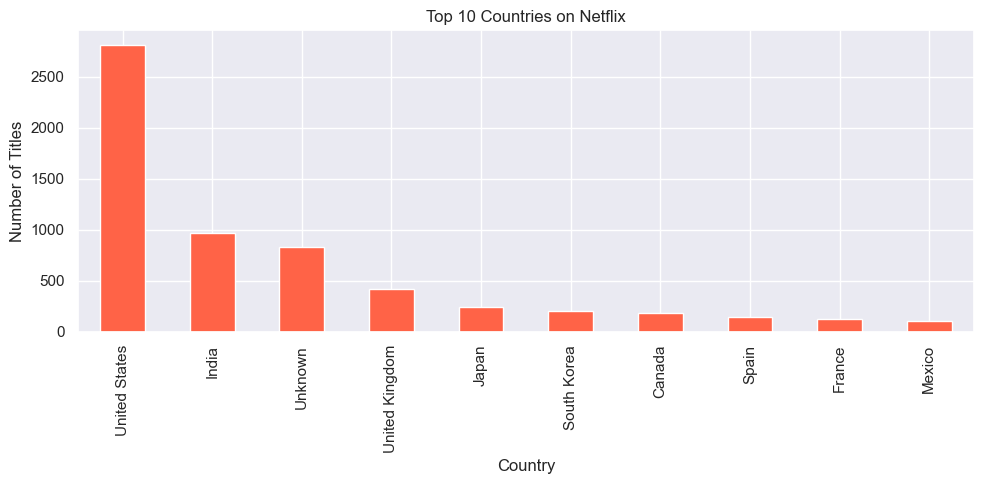

In [21]:
top_countries = df["country"].value_counts().head(10)
top_countries.plot(kind="bar", figsize=(10,5), color="tomato")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("charts/top_countries.png")
plt.show()

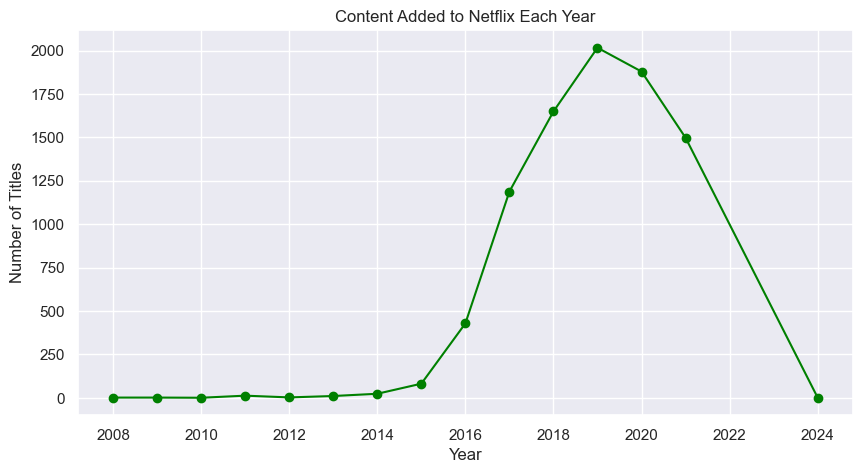

In [24]:
df["year_added"].value_counts().sort_index().plot(kind="line", figsize=(10,5), marker="o", color="green")
plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.savefig("charts/content_per_year.png")
plt.show()

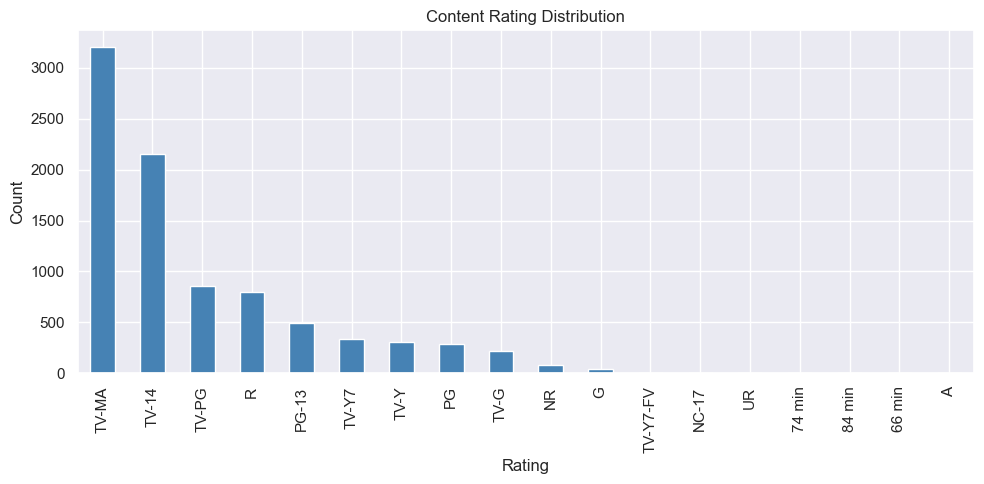

In [25]:
df["rating"].value_counts().plot(kind="bar", figsize=(10,5), color="steelblue")
plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/ratings.png")
plt.show()

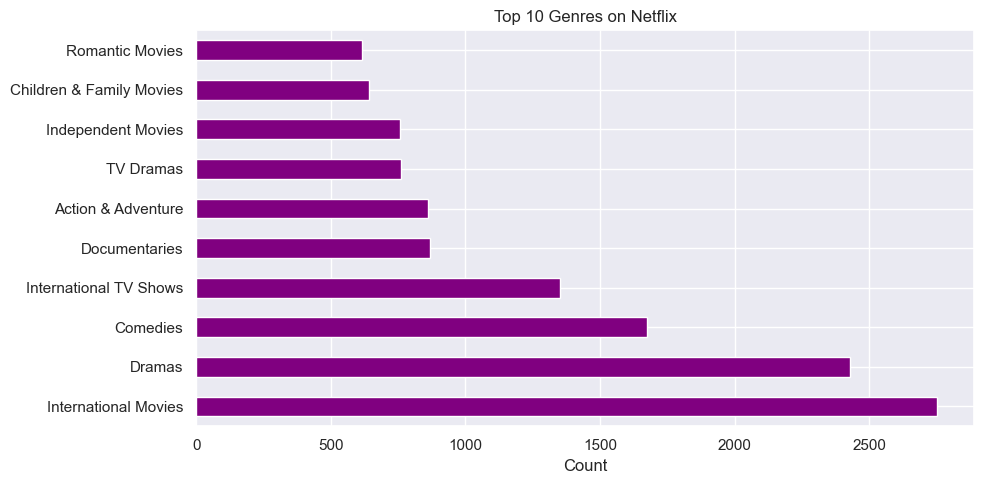

In [26]:
# Genres are comma-separated in "listed_in" column
from collections import Counter

genres = df["listed_in"].str.split(", ").explode()
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)

top_genres.plot(kind="barh", figsize=(10,5), color="purple")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("charts/top_genres.png")
plt.show()

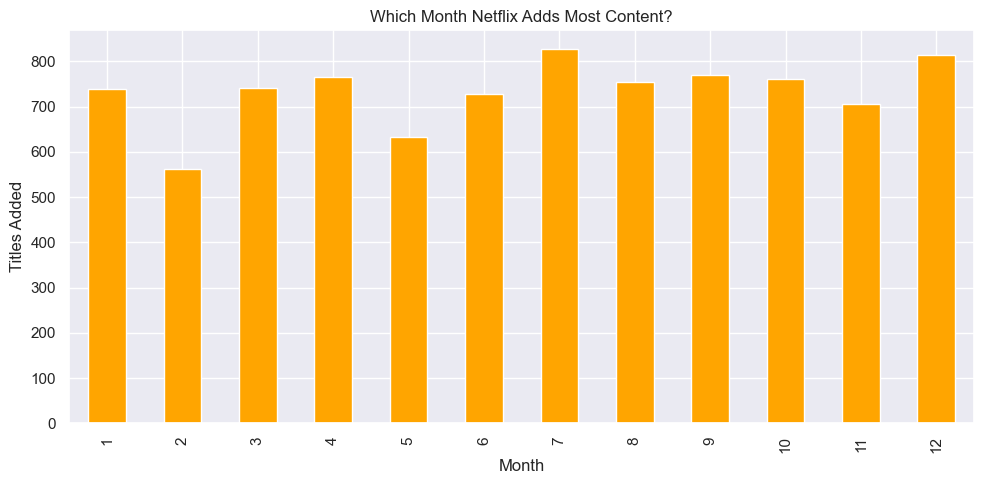

In [27]:
df["month_added"].value_counts().sort_index().plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Which Month Netflix Adds Most Content?")
plt.xlabel("Month")
plt.ylabel("Titles Added")
plt.tight_layout()
plt.savefig("charts/month_added.png")
plt.show()

## Key Insights
- 70% of Netflix content is Movies, 30% is TV Shows
- USA produces the most content by far
- Netflix added the most content between 2018–2020
- TV-MA is the most common rating (adult content dominates)
- Dramas and Comedies are the top genres
- Netflix adds most content in January and July